<a href="https://colab.research.google.com/github/Anikawi/propuesta_parte1_S100_grupo9/blob/main/Proyecto_Riesgo_Postcompra_Autos_Panama.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fuente 1: ACODECO
## Datos: reclamaciones del sector automotriz en Panamá
## Periodo inicial de prueba: 2022 - 2023 - 2024 - 2025.

# **Objetivo del análisis**

Analizar los factores asociados al riesgo poscompra dentro del sector automotriz en Panamá, utilizando los registros de reclamaciones de ACODECO para los años 2022–2025.

En esta primera fase se realiza:

- carga y unificación de los archivos;
- revisión de calidad de datos;
- limpieza de texto y valores faltantes;
- análisis descriptivo;
- creación de un **indicador exploratorio de riesgo** a nivel de reclamación;
- análisis por año, marca y actividad.

> **Importante:** el indicador `Nivel_Riesgo` que se construye en este cuaderno es una herramienta exploratoria. No representa todavía la tasa final de riesgo poscompra por marca. Para esa etapa será necesario integrar las ventas de vehículos de ADAP y calcular reclamaciones en relación con el volumen vendido.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# 2. Carga y exploración inicial de los datos



In [2]:
df_2022 = pd.read_csv("decisiondequejas_csv2022.csv", sep=",", encoding="latin1")
df_2023 = pd.read_csv("decision_2023.csv", sep=";", encoding="latin1")
df_2024 = pd.read_csv("decision-de-quejas-2024.csv", sep=";", encoding="latin1")
df_2025 = pd.read_csv("decisionquejas_2025.csv", sep=";", encoding="latin1")

print("Cuántas filas y columnas tiene cada archivo?")
print("2022:", df_2022.shape)
print("2023:", df_2023.shape)
print("2024:", df_2024.shape)
print("2025:", df_2025.shape)

Cuántas filas y columnas tiene cada archivo?
2022: (1056, 17)
2023: (2010, 17)
2024: (1915, 17)
2025: (2063, 17)


In [3]:
print("Existen filas completamente vacias?")

print("2022:", df_2022.isna().all(axis=1).sum())
print("2023:", df_2023.isna().all(axis=1).sum())
print("2024:", df_2024.isna().all(axis=1).sum())
print("2025:", df_2025.isna().all(axis=1).sum())

Existen filas completamente vacias?
2022: 280
2023: 0
2024: 0
2025: 0


In [4]:
df_2022 = df_2022.dropna(how="all")
df_2023 = df_2023.dropna(how="all")
df_2024 = df_2024.dropna(how="all")
df_2025 = df_2025.dropna(how="all")

In [5]:
print("2022:", df_2022.shape)
print("2023:", df_2023.shape)
print("2024:", df_2024.shape)
print("2025:", df_2025.shape)

2022: (776, 17)
2023: (2010, 17)
2024: (1915, 17)
2025: (2063, 17)


## 2.1 Cuáles nombres de columnas no coinciden?

In [6]:
print(df_2022.columns.tolist())
print(df_2023.columns.tolist())
print(df_2024.columns.tolist())
print(df_2025.columns.tolist())

['Departamento  de la Instituci¢n', 'Provincias dela Rep£blica  de Panam\xa0', 'Tipo de Ley', 'Fecha de Entrada de Queja', 'Mes de Entrada de Queja', 'Motivo de Queja', 'Agente Econ¢mico', 'Actividad', 'Marca de Producto', 'Producto', 'Velor de Apertura de Queja', 'Resultado de Queja', 'Efectivo Devuelto al Consumidor (B/.)', 'Fecha de Cierre de Queja', 'Mes Cierre de Queja', 'A¤o Cierre de Queja', 'A¤o Recibido de Queja']
['Departamento  de la Instituci¢n', 'Provincias dela Rep£blica  de Panam\xa0', 'Tipo de Ley', 'Fecha de Entrada de Queja', 'Mes de Entrada de Queja', 'Motivo de Queja', 'Agente Econ¢mico', 'Actividad', 'Marca de Producto', 'Producto', 'Velor de Apertura de Queja', 'Resultado de Queja', 'Efectivo Devuelto al Consumidor (B/.)', 'Fecha de Cierre de Queja', 'Mes Cierre de Queja', 'A¤o Cierre de Queja', 'A¤o Recibido de Queja']
['Departamento  de la Instituci¢n', 'Provincias dela Rep£blica  de Panam\xa0', 'Tipo de Ley', 'Fecha de Entrada de Queja', 'Mes de Entrada de Quej

## 2.2 Renombrar las columnas para que los 4 archivos tengan la misma columna (homologacion)

In [7]:
df_2022.columns = df_2025.columns
df_2023.columns = df_2025.columns
df_2024.columns = df_2025.columns

Esto funciona en nuestros archivos porque previamente comprobamos que tienen las mismas 17 columnas y mantienen el mismo orden

## 2.3 Combinamos los 4 registros

In [8]:
df = pd.concat(
    [df_2022, df_2023, df_2024, df_2025],
    ignore_index=True
)

df.shape

(6764, 17)

## 2.4 Mostrar los primeros 5 registros

como vemos es un registro que recopila quejas de todo tipo a instituciones de todo tipo. entre ellas incluida AUTOS/AUTOMOVILES que es lo que nos interesa. tiene valores sucios y casillas NaN que hay que descartar o no


In [9]:
df.head()

,Departamento de la Institución,Provincias dela República de Panamá,Tipo de Ley,Fecha de Entrada de Queja,Mes de Entrada de Queja,Motivo de Queja,Agente Económico,Actividad,Marca de Producto,Producto,Velor de Apertura de Queja,Resultado de Queja,Efectivo Devuelto al Consumidor (B/.),Fecha de Cierre de Queja,Mes Cierre de Queja,Año Cierre de Queja,Año Recibido de Queja
0,Veh¡culo a Motor,Panam,Ley 45 de 2007,03-ene-2022,Ene,Incumplimiento de garant¡a,AUTOS COOL S.A.,Venta de autos usados,KIA,Auto,"3,000.00",En proceso,NaN,NaN,NaN,NaN,2022.0
1,Decisi¢n,Panam,Ley 45 de 2007,03-ene-2022,Ene,Incumplimiento de garant¡a,FEWORITE,Celulares,No se Registro,Celular,246.10,Desistimiento,NaN,31-ene-2022,Ene 22,2022.0,2022.0
2,Veh¡culo a Motor,Panam,Ley 45 de 2007,04-ene-2022,Ene,Da¤os y perjuicios,GLOBAL IMPORT AND PARTS,Taller de reparaci¢n de autos,Honda,Auto,"2,319.93",En proceso,NaN,NaN,NaN,NaN,2022.0
3,Decisi¢n,Panam,Ley 45 de 2007,03-ene-2022,Ene,Custodia de bien,MOVIL HOME,Celulares,Samsung,Celular,80.00,Desistimiento/Devoluci¢n,80.00,28-mar-2022,Mar 22,2022.0,2022.0
4,Decisi¢n,Panam,Ley 45 de 2007,03-ene-2022,Ene,Incumplimiento de garant¡a,SKY MASTER ENTERPRISES INC,Inmobiliarias,No se Registro,No se Registro,631.30,En proceso,NaN,NaN,NaN,NaN,2022.0


## 2.5 Consultar el formato de cada columna

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6764 entries, 0 to 6763
Data columns (total 17 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Departamento  de la Institución        6764 non-null   object 
 1   Provincias dela República  de Panamá   6764 non-null   object 
 2   Tipo de Ley                            6764 non-null   object 
 3   Fecha de Entrada de Queja              6764 non-null   object 
 4   Mes de Entrada de Queja                6764 non-null   object 
 5   Motivo de Queja                        6764 non-null   object 
 6   Agente Económico                       6764 non-null   object 
 7   Actividad                              6764 non-null   object 
 8   Marca de Producto                      5458 non-null   object 
 9   Producto                               5757 non-null   object 
 10  Velor de Apertura de Queja             6764 non-null   object 
 11  Resu

# 3. Revisión de variables relevantes para el análisis

## 3.1 Cómo viene la variable obj

In [11]:
df["Resultado de Queja"].value_counts(dropna=False)

,count
Resultado de Queja,
En proceso,4081
Desistimiento,952
Acuerdo en audiencia/Varios,398
Pendiente constancia desistimiento,365
Desistimiento/Devoluci¢n,191
Acuerdo en audiencia/Devoluci¢n de dinero,119
Desistimiento/Devolución,89
Corregidur¡a/Casa de Justicia Comunitaria de Paz,61
Resoluciones/Varios,51


## 3.2 Limpieza de la variable obj



In [12]:
df["Resultado de Queja"] = df["Resultado de Queja"].replace({
    "Desistimiento/Devoluci¢n":                           "Desistimiento/Devolución",
    "Ministerio P£blico":                                 "Ministerio Público",
    "Corregidur¡a/Casa de Justicia Comunitaria de Paz":   "Corregiduría/Casa de Justicia Comunitaria de Paz",
    "Resoluci¢n/Devoluci¢n":                              "Resolución/Devolución",
    "Transacci¢n extrajudicial":                          "Transacción extrajudicial",
    "Resoluci¢n/Reemplazo":                               "Resolución/Reemplazo",
    "Acuerdo en audiencia/Reparaci¢n":                    "Acuerdo en audiencia/Reparación",
    "Resoluci¢n/Reparar":                                 "Resolución/Reparar",
    "Ordena correcci¢n":                                  "Ordena corrección",
    "Acuerdo en audiencia/Aclaraci¢n":                    "Acuerdo en audiencia/Aclaración",
    "Temporal Pendiente de notificaci¢n":                 "Temporal Pendiente de notificación",
    "Acuerdo/Devoluci¢n":                                 "Acuerdo/Devolución",
    "Resoluci¢n no acceder":                              "Resolución no acceder",
    "Acuerdo en audiencia/Devoluci¢n de dinero":          "Acuerdo en audiencia/Devolución de dinero",
    "Acuerdo/Reparaci¢n":                                 "Acuerdo/Reparación",
})

In [13]:
df["Resultado de Queja"].value_counts()

,count
Resultado de Queja,
En proceso,4081
Desistimiento,952
Acuerdo en audiencia/Varios,398
Pendiente constancia desistimiento,365
Desistimiento/Devolución,280
Acuerdo en audiencia/Devolución de dinero,139
Corregiduría/Casa de Justicia Comunitaria de Paz,67
Resoluciones/Varios,51
Acuerdo en audiencia/Reemplazo,50


## 3.3 Filtrar solo los casos relacionados con automóviles y contar cuántos registros tenemos

In [14]:
for anio, datos in [
    ("2022", df_2022),
    ("2023", df_2023),
    ("2024", df_2024),
    ("2025", df_2025)
]:
    cantidad = len(
        datos[
            (datos["Actividad"] == "Agencia de autos") &
            (datos["Producto"].isin(["Auto", "Automóvil"]))
        ]
    )

    print(anio, cantidad)

2022 42
2023 94
2024 144
2025 177


In [15]:
df_autos = df[
    (df["Actividad"] == "Agencia de autos") &
    (df["Producto"].isin(["Auto","Automóvil"]))
].copy()

df_autos.shape

(457, 17)

### ¿Por qué se revisaron los productos por año?

Se realizó una revisión más profunda porque, al trabajar con **cuatro años de información**, era extraño que el filtro inicial devolviera pocos registros.

La exploración mostró que los nombres del producto no son completamente uniformes entre años. Por ejemplo, aparecen valores como `Auto` y `Automóvil`.

Por esta razón, el filtro utiliza ambos valores para evitar perder reclamaciones válidas.

In [16]:
actividades_autos = [
    "Agencia de autos",
    "Venta de autos usados",
    "Taller de reparación de autos",
    "Repuestos para autos",
    "Alquiler de autos"
]

df_sector_auto = df[                     #DATAFRAME QUE CONTIENE SOLO RECLAMACIONES RELACIONADAS CON EL SECTOR AUTOMOTRIZ
    df["Actividad"].isin(actividades_autos)
].copy()

df_sector_auto.shape

(1141, 17)

In [18]:
reemplazos_texto = {
    "Bater¡a de auto": "Batería de auto",
    "Transmisi¢n": "Transmisión",
    "Incumplimiento de garant¡a": "Incumplimiento de garantía",
    "Falta de informaci¢n": "Falta de información",
    "Devoluci¢n de dinero": "Devolución de dinero",
    "Venta enga¤osa": "Venta engañosa",
    "Da¤os y perjuicios": "Daños y perjuicios",
    "Mercanc¡a defectuosa": "Mercancía defectuosa"
}

for col in ["Producto", "Motivo de Queja"]:
    df_sector_auto[col] = df_sector_auto[col].replace(reemplazos_texto)

In [19]:
columnas_texto = [
    "Actividad",
    "Marca de Producto",
    "Producto",
    "Motivo de Queja",
    "Resultado de Queja"
]

for col in columnas_texto:
    print(f"\n--- {col} ---")

    valores_sospechosos = df_sector_auto.loc[
        df_sector_auto[col].astype(str).str.contains(
            r"[¡¢£¤]",
            regex=True,
            na=False
        ),
        col
    ].drop_duplicates()

    print(valores_sospechosos.tolist())


--- Actividad ---
[]

--- Marca de Producto ---
[]

--- Producto ---
[]

--- Motivo de Queja ---
[]

--- Resultado de Queja ---
[]


In [20]:
len(df_sector_auto)

1141

In [21]:
df_sector_auto["Actividad"].value_counts()

,count
Actividad,
Agencia de autos,480
Venta de autos usados,350
Repuestos para autos,185
Taller de reparación de autos,98
Alquiler de autos,28


¿Por qué usamos **Actividad**?
Porque permite identificar y agrupar los registros relacionados con el sector automotriz. Más adelante podrá utilizarse como una variable explicativa para analizar diferencias en el riesgo entre agencias, ventas, talleres, repuestos y alquileres.



# 4. Revisión de valores faltantes del sector automotriz para el dataset df_sector_auto

## 4.1 Cuáles columnas tienen NaN dentro de df_sector_auto

In [22]:
nulos_sector = pd.DataFrame({
    "Cantidad": df_sector_auto.isna().sum(),
    "Porcentaje": (df_sector_auto.isna().mean() * 100).round(2)
})

nulos_sector = nulos_sector[nulos_sector["Cantidad"] > 0]

nulos_sector.sort_values("Cantidad", ascending=False)

,Cantidad,Porcentaje
Efectivo Devuelto al Consumidor (B/.),1125,98.60
Fecha de Cierre de Queja,951,83.35
Mes Cierre de Queja,951,83.35
Año Cierre de Queja,951,83.35
Marca de Producto,53,4.65
Producto,16,1.40




*  Mes Cierre de Queja
*  Fecha de Cierre de Queja
*  Año Cierre de Queja
### tienen los mismo valores NaN lo que puede ser que esos casos esten en PROCESO(todavia no tienen fecha de cierre)


*   Efectivo Devuelto al Consumidor (B/.)
### tiene 1238 NaN. No debemos asumir que todos significan 0; primero hay que comprobar si depende del **Resultado de Queja**.


*   Marca de Producto y Producto
### tienen pocos faltantes, 53 y 16 respectivamente, así que esos sí se puede decidir luego si imputar/eliminar.







## 4.2 Analizar si los valores faltantes tienen una explicación

### 4.2.1 para las fechas:


In [23]:
df_sector_auto.loc[
    df_sector_auto["Fecha de Cierre de Queja"].isna(),
    "Resultado de Queja"
].value_counts()

,count
Resultado de Queja,
En proceso,951


se confirma que son quejas en proceso...

### 4.2.2 para Efectivo Devuelto al  Consumidor (B/.)

---



In [24]:
df_sector_auto.loc[
    df_sector_auto["Efectivo Devuelto al Consumidor (B/.)"].isna(),
    "Resultado de Queja"
].value_counts() #.sum()

,count
Resultado de Queja,
En proceso,951
Desistimiento,112
Pendiente constancia desistimiento,20
Acuerdo en audiencia/Varios,13
Ministerio Público,6
Acuerdo en audiencia/Devolución de dinero,5
Transacción extrajudicial,4
Inadmitida,3
Desistimiento/Devolución,2


se confirma que tiene relacion pero nan no es 0, significa que esta columna tiene faltantes reales o casos donde no aplica

revisar casos donde si hay devoluciones de dinero:

In [25]:
df_sector_auto.loc[
    df_sector_auto["Efectivo Devuelto al Consumidor (B/.)"].notna(),
    ["Resultado de Queja", "Efectivo Devuelto al Consumidor (B/.)"]
]

,Resultado de Queja,Efectivo Devuelto al Consumidor (B/.)
235,Acuerdo en audiencia/Devolución de dinero,201.96
982,Acuerdo en audiencia/Devolución de dinero,100.0
1144,Acuerdo en audiencia/Devolución de dinero,51.36
1145,Acuerdo en audiencia/Devolución de dinero,500.0
1351,Desistimiento/Devolución,42.37
1869,Acuerdo en audiencia/Devolución de dinero,79.18
2033,Desistimiento,90.0
2975,Acuerdo en audiencia/Devolución de dinero,55.0
2981,Acuerdo en audiencia/Devolución de dinero,7190.0
2983,Acuerdo en audiencia/Devolución de dinero,100.0


In [26]:
df_sector_auto["Efectivo Devuelto al Consumidor (B/.)"].notna().sum()

np.int64(16)

La variable `Efectivo Devuelto al Consumidor (B/.)` contiene información en muy pocos registros del sector automotriz.

La celda anterior calcula la cantidad y el porcentaje de forma automática. Debido al alto porcentaje de valores faltantes, esta variable **no se utilizará inicialmente para construir el indicador de riesgo**.

No se elimina del archivo original: simplemente se excluye del conjunto de variables del modelo exploratorio.

In [27]:
total = len(df_sector_auto)

con_dato = df_sector_auto["Efectivo Devuelto al Consumidor (B/.)"].notna().sum()
sin_dato = df_sector_auto["Efectivo Devuelto al Consumidor (B/.)"].isna().sum()

porcentaje_con_dato = (con_dato / total) * 100
porcentaje_sin_dato = (sin_dato / total) * 100

print("Total de registros:", total)
print("Con dato:", con_dato, f"({porcentaje_con_dato:.2f}%)")
print("Sin dato:", sin_dato, f"({porcentaje_sin_dato:.2f}%)")

Total de registros: 1141
Con dato: 16 (1.40%)
Sin dato: 1125 (98.60%)


con un  porcentaje de 98% se pensaria que es mejor descartarla pero es mejor prevenir y hacer una analisis

### 4.2.3 para Marca de producto y Producto

In [28]:
df_sector_auto.loc[
    df_sector_auto["Marca de Producto"].isna(),
    ["Actividad", "Producto", "Motivo de Queja", "Resultado de Queja"]
].head(20)

,Actividad,Producto,Motivo de Queja,Resultado de Queja
2897,Agencia de autos,Auto,Incumplimiento de garantía,En proceso
2910,Repuestos para autos,NaN,Devolución de dinero,Desistimiento
2913,Repuestos para autos,NaN,Devolución de dinero,En proceso
3141,Agencia de autos,NaN,Veracidad de la publicidad,Desistimiento
3161,Alquiler de autos,Auto,Falta de información,Desistimiento
3260,Venta de autos usados,Auto,Incumplimiento de garantía,En proceso
3298,Repuestos para autos,NaN,Incumplimiento de servicio,En proceso
3334,Repuestos para autos,Batería de auto,Incumplimiento de garantía,En proceso
3452,Agencia de autos,Auto,Incumplimiento de garantía,En proceso
3453,Agencia de autos,Auto,Incumplimiento de garantía,En proceso


In [29]:
df_sector_auto.loc[
    df_sector_auto["Producto"].isna(),
    ["Actividad", "Marca de Producto", "Motivo de Queja", "Resultado de Queja"]
].head(20)

,Actividad,Marca de Producto,Motivo de Queja,Resultado de Queja
2910,Repuestos para autos,NaN,Devolución de dinero,Desistimiento
2913,Repuestos para autos,NaN,Devolución de dinero,En proceso
3141,Agencia de autos,NaN,Veracidad de la publicidad,Desistimiento
3298,Repuestos para autos,NaN,Incumplimiento de servicio,En proceso
3602,Repuestos para autos,NaN,Incumplimiento de servicio,En proceso
3747,Repuestos para autos,NaN,Daños y perjuicios,Pendiente constancia desistimiento
3757,Repuestos para autos,NaN,Incumplimiento de garantía,En proceso
3871,Agencia de autos,NaN,Devolución de dinero,En proceso
3914,Repuestos para autos,NaN,Incumplimiento de garantía,En proceso
4080,Repuestos para autos,NaN,Custodia de bien,En proceso


En varios casos, aunque **Producto/Marca de Producto** esté vacío, la **Actividad** ya indica claramente que el registro pertenece al sector automotriz, por ejemplo Repuestos para autos o Agencia de autos

se decidio reemplazar esos NaN por algo mas descriptivo:

In [30]:
df_sector_auto["Marca de Producto"] = df_sector_auto["Marca de Producto"].fillna("No registrado")

df_sector_auto["Producto"] = df_sector_auto["Producto"].fillna("No registrado")

In [31]:
df_sector_auto[["Marca de Producto", "Producto"]].isna().sum()

,0
Marca de Producto,0
Producto,0


In [32]:
df_sector_auto[
    ["Actividad", "Marca de Producto", "Producto", "Motivo de Queja", "Resultado de Queja"]
].head(50)

,Actividad,Marca de Producto,Producto,Motivo de Queja,Resultado de Queja
0,Venta de autos usados,KIA,Auto,Incumplimiento de garantía,En proceso
7,Venta de autos usados,Hyundai,Auto,Incumplimiento de garantía,Desistimiento
9,Venta de autos usados,Volvo,Auto,Incumplimiento de garantía,Desistimiento
11,Agencia de autos,Suzuki,Auto,Incumplimiento de garantía,Desistimiento
12,Repuestos para autos,No se Registro,No se Registro,Incumplimiento de garantía,En proceso
17,Venta de autos usados,Audi,Auto,Incumplimiento de garantía,En proceso
18,Agencia de autos,No se Registro,Auto,Falta de información,Desistimiento
21,Repuestos para autos,Mazda,Auto,Incumplimiento de servicio,En proceso
22,Agencia de autos,No se Registro,Auto,Falta de información,En proceso
27,Repuestos para autos,No se Registro,No se Registro,Incumplimiento de garantía,Desistimiento


## 5. Qué columnas vamos a conservar para construir la clasificación de riesgo Alto / Medio / Bajo y cuáles no nos aportan al modelo?**texto en negrita**

### 5.3.1 Separar las columnas utiles

In [33]:
columnas_utiles = [
    "Fecha de Entrada de Queja",
    "Año Recibido de Queja",
    "Agente Económico",
    "Actividad",
    "Marca de Producto",
    "Producto",
    "Motivo de Queja",
    "Velor de Apertura de Queja",
    "Resultado de Queja"
]

¿Por qué?

Porque después podremos responder:

¿Las reclamaciones aumentan por año?
¿Qué distribuidor recibe las reclamaciones?
¿Qué marcas crecen o disminuyen?

In [34]:
df_modelo = df_sector_auto[columnas_utiles].copy()

In [35]:
df_modelo.head()

,Fecha de Entrada de Queja,Año Recibido de Queja,Agente Económico,Actividad,Marca de Producto,Producto,Motivo de Queja,Velor de Apertura de Queja,Resultado de Queja
0,03-ene-2022,2022.0,AUTOS COOL S.A.,Venta de autos usados,KIA,Auto,Incumplimiento de garantía,"3,000.00",En proceso
7,05-ene-2022,2022.0,PTY CAR SERVICES GROUP,Venta de autos usados,Hyundai,Auto,Incumplimiento de garantía,"18,500.00",Desistimiento
9,05-ene-2022,2022.0,"DASOO, S.A.",Venta de autos usados,Volvo,Auto,Incumplimiento de garantía,"7,700.00",Desistimiento
11,05-ene-2022,2022.0,MOTORES JAPONESES,Agencia de autos,Suzuki,Auto,Incumplimiento de garantía,"14,490.00",Desistimiento
12,06-ene-2022,2022.0,AUTOMOTORES BARRIGA,Repuestos para autos,No se Registro,No se Registro,Incumplimiento de garantía,"8,095.00",En proceso


In [36]:
df_modelo.shape

(1141, 9)

# 6. Cómo se distribuyen estas columnas?, sobre todo Motivo de Queja, Valor de Apertura de Queja y Resultado de Queja, para decidir con qué lógica construiremos el riesgo.

In [37]:
df_modelo["Motivo de Queja"].value_counts()

,count
Motivo de Queja,
Incumplimiento de garantía,753
Falta de información,169
Incumplimiento de servicio,86
Custodia de bien,41
Devolución de dinero,29
Incumplimiento de contrato,20
Vicio oculto,19
Daños y perjuicios,7
Cobro indebido,7


In [38]:
df_modelo["Resultado de Queja"].value_counts()

,count
Resultado de Queja,
En proceso,951
Desistimiento,114
Pendiente constancia desistimiento,20
Acuerdo en audiencia/Devolución de dinero,16
Acuerdo en audiencia/Varios,13
Ministerio Público,6
Desistimiento/Devolución,5
Transacción extrajudicial,4
Inadmitida,3


In [39]:
df_modelo["Velor de Apertura de Queja"].describe()

,Velor de Apertura de Queja
count,1141.0
unique,921.0
top,5000.0
freq,7.0


In [40]:
df_modelo["Velor de Apertura de Queja"].dtype

dtype('O')

segun el describe y el .dtype parece estar tratándolo como texto y no como número.

In [41]:
print("Tipo actual:", df_modelo["Velor de Apertura de Queja"].dtype)
print("\nEjemplos de valores antes de convertir:")
display(df_modelo[["Velor de Apertura de Queja"]].head(10))

Tipo actual: object

Ejemplos de valores antes de convertir:


,Velor de Apertura de Queja
0,"3,000.00"
7,"18,500.00"
9,"7,700.00"
11,"14,490.00"
12,"8,095.00"
17,"5,220.00"
18,500.00
21,"2,824.34"
22,91.40
27,69.83


Antes de calcular media, mediana o desviación estándar debemos confirmar que el monto sea numérico.

En este punto la columna todavía viene como texto (`object`), por lo que primero se diagnostica el formato y después se realiza la conversión.

## 6.1 Convertir el valor de apertura a un tipo numerico

In [42]:
df_modelo["Velor de Apertura de Queja"] = pd.to_numeric(
    df_modelo["Velor de Apertura de Queja"],
    errors="coerce"
)

In [43]:
df_modelo["Velor de Apertura de Queja"].dtype

dtype('float64')

In [44]:
df_modelo["Velor de Apertura de Queja"].describe()

,Velor de Apertura de Queja
count,700.000000
mean,7524.606171
std,9119.448541
min,0.000000
25%,296.657500
50%,2092.120000
75%,14995.000000
max,30000.000000


In [45]:
print("Total de registros:", len(df_modelo))

print(
    "Valores numéricos válidos:",
    df_modelo["Velor de Apertura de Queja"].notna().sum()
)

print(
    "Valores NaN:",
    df_modelo["Velor de Apertura de Queja"].isna().sum()
)

Total de registros: 1141
Valores numéricos válidos: 700
Valores NaN: 441


In [46]:
conversion = pd.to_numeric(
    df_sector_auto["Velor de Apertura de Queja"],
    errors="coerce"
)

valores_no_convertidos = df_sector_auto.loc[
    conversion.isna() &
    df_sector_auto["Velor de Apertura de Queja"].notna(),
    "Velor de Apertura de Queja"
]

valores_no_convertidos.value_counts()

,count
Velor de Apertura de Queja,
"1,000.00",6
"7,000.00",5
"5,500.00",5
"3,000.00",5
"8,000.00",5
...,...
"21,075.00",1
"4,526.10",1
"5,243.00",1


lo esta tomando como NaN porque tiene ,

In [47]:
df_modelo["Velor de Apertura de Queja"] = (
    df_sector_auto["Velor de Apertura de Queja"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

In [48]:
df_modelo["Velor de Apertura de Queja"] = pd.to_numeric(
    df_modelo["Velor de Apertura de Queja"],
    errors="coerce"
)

In [49]:
print("Válidos:", df_modelo["Velor de Apertura de Queja"].notna().sum())
print("NaN:", df_modelo["Velor de Apertura de Queja"].isna().sum())

Válidos: 1141
NaN: 0


## 6.2 Estadística descriptiva del monto

Ahora que `Velor de Apertura de Queja` es una variable numérica, se pueden aplicar medidas vistas en clase:

- **media**: promedio de los montos;
- **mediana**: valor central;
- **desviación estándar**: dispersión respecto a la media;
- **rango**: diferencia entre el máximo y el mínimo.

Comparar media y mediana ayuda a detectar si los valores altos están empujando el promedio.

In [50]:
monto = df_modelo["Velor de Apertura de Queja"]

resumen_monto = pd.Series({
    "Media": monto.mean(),
    "Mediana": monto.median(),
    "Desviación estándar": monto.std(),
    "Mínimo": monto.min(),
    "Máximo": monto.max(),
    "Rango": monto.max() - monto.min()
})

resumen_monto.round(2)

,0
Media,9379.57
Mediana,5885.00
Desviación estándar,9352.10
Mínimo,0.00
Máximo,30000.00
Rango,30000.00


# 7. Observar los cuartiles del monto(asi no se inventan los límites)

In [51]:
df_modelo["Velor de Apertura de Queja"].quantile([0.25, 0.50, 0.75])

,Velor de Apertura de Queja
0.25,770.22
0.50,5885.00
0.75,17850.00


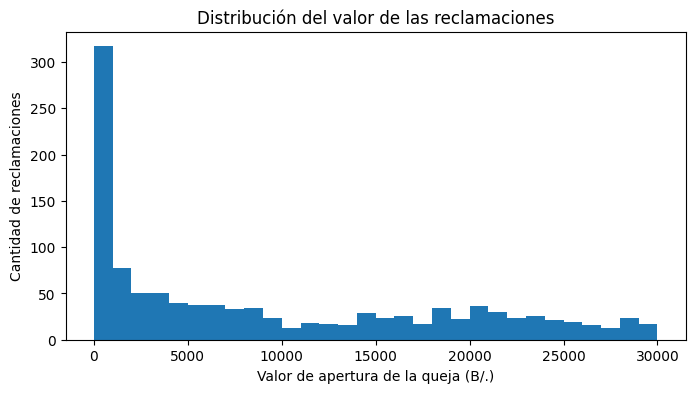

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

plt.hist(
    df_modelo["Velor de Apertura de Queja"],
    bins=30
)

plt.title("Distribución del valor de las reclamaciones")
plt.xlabel("Valor de apertura de la queja (B/.)")
plt.ylabel("Cantidad de reclamaciones")

plt.show()

In [53]:
asimetria = df_modelo["Velor de Apertura de Queja"].skew()

print("Asimetría:", asimetria)

Asimetría: 0.6657697015411983


La distribución presenta asimetría positiva, lo que indica que existen algunas reclamaciones con montos considerablemente superiores al resto.

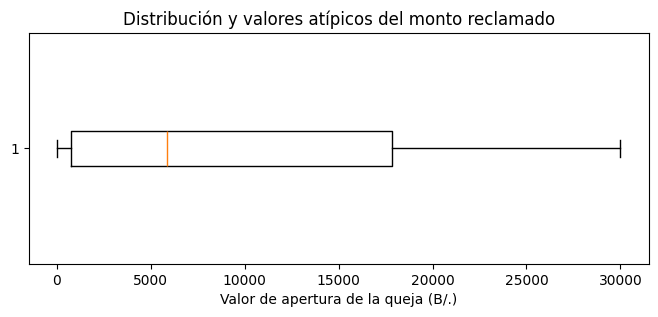

In [54]:
plt.figure(figsize=(8, 3))

plt.boxplot(
    df_modelo["Velor de Apertura de Queja"],
    vert=False
)

plt.title("Distribución y valores atípicos del monto reclamado")
plt.xlabel("Valor de apertura de la queja (B/.)")

plt.show()

## 7.1 Identificación de valores atípicos con la regla 1.5 × IQR

El boxplot permite observar visualmente valores extremos. Para comprobarlo de forma numérica aplicamos la regla vista en clase:

- `IQR = Q3 - Q1`
- límite inferior = `Q1 - 1.5 × IQR`
- límite superior = `Q3 + 1.5 × IQR`

Un valor fuera de esos límites se marca como **posible valor atípico**. No se elimina automáticamente: primero debe revisarse, porque un monto alto puede ser una reclamación real.

In [55]:
q1_iqr = df_modelo["Velor de Apertura de Queja"].quantile(0.25)
q3_iqr = df_modelo["Velor de Apertura de Queja"].quantile(0.75)
iqr = q3_iqr - q1_iqr

limite_inferior = q1_iqr - 1.5 * iqr
limite_superior = q3_iqr + 1.5 * iqr

outliers_monto = df_modelo[
    (df_modelo["Velor de Apertura de Queja"] < limite_inferior) |
    (df_modelo["Velor de Apertura de Queja"] > limite_superior)
].copy()

print("Q1:", round(q1_iqr, 2))
print("Q3:", round(q3_iqr, 2))
print("IQR:", round(iqr, 2))
print("Límite inferior:", round(limite_inferior, 2))
print("Límite superior:", round(limite_superior, 2))
print("Posibles valores atípicos:", len(outliers_monto))

Q1: 770.22
Q3: 17850.0
IQR: 17079.78
Límite inferior: -24849.45
Límite superior: 43469.67
Posibles valores atípicos: 0


# 8. Variable objetivo: Nivel de Riesgo (Bajo / Medio / Alto) Diseñar reglas de puntuacion

## 8.1 clasificar los motivos de queja por nivel de impacto

In [56]:
riesgo_motivo = {
    "Falta de información": 0,

    "Venta engañosa": 1,
    "Incumplimiento de servicio": 1,
    "Incumplimiento de contrato": 1,
    "Custodia de bien": 1,
    "Cobro indebido": 1,
    "Veracidad de la publicidad": 1,

    "Incumplimiento de garantía": 2,
    "Devolución de dinero": 2,
    "Daños y perjuicios": 2,
    "Mercancía defectuosa": 2,
    "Vicio oculto": 2
}



*  0 = impacto bajo
*  1 = impacto medio
*  2 = impacto alto




## 8.2 Asignar puntuación según Resultado de Queja

Se asigna una puntuación exploratoria de 0, 1 o 2 según el tipo de resultado.

> **Advertencia metodológica:** esta escala fue definida para explorar los datos y debe interpretarse con cautela. Categorías administrativas como `Inadmitida`, `Caducidad de la instancia` o `Resolución no acceder` no necesariamente implican que la marca haya tenido una conducta más riesgosa. Antes de usar este indicador como medida definitiva se debe validar el significado de estas categorías con la documentación de ACODECO.

In [57]:
riesgo_resultado = {
    # 0 puntos - favorable
    "Acuerdo en audiencia/Devolución de dinero": 0,
    "Acuerdo en audiencia/Reparación": 0,
    "Acuerdo en audiencia/Aclaración": 0,
    "Acuerdo en audiencia/Varios": 0,
    "Ordena corrección": 0,

    # 1 punto - pendiente o sin resolución definitiva
    "En proceso": 1,
    "Pendiente constancia desistimiento": 1,
    "Desistimiento": 1,
    "Desistimiento/Devolución": 1,
    "Transacción extrajudicial": 1,
    "Abandono": 1,

    # 2 puntos - escalado o desfavorable
    "Ministerio Público": 2,
    "Corregiduría/Casa de Justicia Comunitaria de Paz": 2,
    "Inadmitida": 2,
    "Inhibe": 2,
    "Caducidad de la instancia": 2,
    "Resolución no acceder": 2
}

In [58]:
df_modelo["Puntos_Resultado"] = df_modelo["Resultado de Queja"].map(riesgo_resultado)

¿Hay algún Resultado de Queja al que olvidamos asignarle puntos?:

In [59]:
df_modelo.loc[
    df_modelo["Puntos_Resultado"].isna(),
    "Resultado de Queja"
].value_counts()

,count
Resultado de Queja,


In [60]:
df_modelo[
    ["Resultado de Queja", "Puntos_Resultado"]
].head(20)

,Resultado de Queja,Puntos_Resultado
0,En proceso,1
7,Desistimiento,1
9,Desistimiento,1
11,Desistimiento,1
12,En proceso,1
17,En proceso,1
18,Desistimiento,1
21,En proceso,1
22,En proceso,1
27,Desistimiento,1


## 8.3: asignar puntos según el monto reclamado

In [61]:
q1 = df_modelo["Velor de Apertura de Queja"].quantile(0.25)
q3 = df_modelo["Velor de Apertura de Queja"].quantile(0.75)

print("Q1:", q1)
print("Q3:", q3)

def puntuar_monto(valor):
    if valor <= q1:
        return 0
    elif valor <= q3:
        return 1
    else:
        return 2

df_modelo["Puntos_Monto"] = (
    df_modelo["Velor de Apertura de Queja"]
    .apply(puntuar_monto)
)

Q1: 770.22
Q3: 17850.0


# puntuación queda automáticamente ligada a los datos.

In [62]:
df_modelo[
    ["Velor de Apertura de Queja", "Puntos_Monto"]
].head(20)

,Velor de Apertura de Queja,Puntos_Monto
0,3000.00,1
7,18500.00,2
9,7700.00,1
11,14490.00,1
12,8095.00,1
17,5220.00,1
18,500.00,0
21,2824.34,1
22,91.40,0
27,69.83,0


In [63]:
df_modelo["Puntos_Motivo"] = df_modelo["Motivo de Queja"].map(riesgo_motivo)

In [64]:
df_modelo[
    ["Motivo de Queja", "Puntos_Motivo"]
].head(20)

,Motivo de Queja,Puntos_Motivo
0,Incumplimiento de garantía,2
7,Incumplimiento de garantía,2
9,Incumplimiento de garantía,2
11,Incumplimiento de garantía,2
12,Incumplimiento de garantía,2
17,Incumplimiento de garantía,2
18,Falta de información,0
21,Incumplimiento de servicio,1
22,Falta de información,0
27,Incumplimiento de garantía,2


In [65]:
df_modelo["Puntaje_Total"] = (
    df_modelo["Puntos_Motivo"] +
    df_modelo["Puntos_Resultado"] +
    df_modelo["Puntos_Monto"]
)

In [66]:
df_modelo[
    [
        "Motivo de Queja",
        "Puntos_Motivo",
        "Resultado de Queja",
        "Puntos_Resultado",
        "Velor de Apertura de Queja",
        "Puntos_Monto",
        "Puntaje_Total"
    ]
].head(20)

,Motivo de Queja,Puntos_Motivo,Resultado de Queja,Puntos_Resultado,Velor de Apertura de Queja,Puntos_Monto,Puntaje_Total
0,Incumplimiento de garantía,2,En proceso,1,3000.00,1,4
7,Incumplimiento de garantía,2,Desistimiento,1,18500.00,2,5
9,Incumplimiento de garantía,2,Desistimiento,1,7700.00,1,4
11,Incumplimiento de garantía,2,Desistimiento,1,14490.00,1,4
12,Incumplimiento de garantía,2,En proceso,1,8095.00,1,4
17,Incumplimiento de garantía,2,En proceso,1,5220.00,1,4
18,Falta de información,0,Desistimiento,1,500.00,0,1
21,Incumplimiento de servicio,1,En proceso,1,2824.34,1,3
22,Falta de información,0,En proceso,1,91.40,0,1
27,Incumplimiento de garantía,2,Desistimiento,1,69.83,0,3


In [67]:
def clasificar_riesgo(puntaje):
    if puntaje <= 2:
        return "Bajo"
    elif puntaje <= 4:
        return "Medio"
    else:
        return "Alto"

df_modelo["Nivel_Riesgo"] = df_modelo["Puntaje_Total"].apply(clasificar_riesgo)

In [68]:
df_modelo["Nivel_Riesgo"].value_counts()

,count
Nivel_Riesgo,
Medio,648
Alto,265
Bajo,228


In [69]:
df_modelo.groupby("Nivel_Riesgo")["Velor de Apertura de Queja"].describe()

,count,mean,std,min,25%,50%,75%,max
Nivel_Riesgo,,,,,,,,
Alto,265.0,22848.190679,4356.037678,1175.13,20319.300,22795.0,25590.0000,30000.0
Bajo,228.0,1871.073728,2869.180815,0.00,197.215,500.0,2692.5375,16900.0
Medio,648.0,6513.456065,6409.417155,0.00,939.250,4500.0,10992.5000,29495.0


In [70]:
pd.crosstab(
    df_modelo["Nivel_Riesgo"],
    df_modelo["Motivo de Queja"]
)

Motivo de Queja,Cobro indebido,Custodia de bien,Daños y perjuicios,Devolución de dinero,Falta de información,Incumplimiento de contrato,Incumplimiento de garantía,Incumplimiento de servicio,Mercancía defectuosa,Venta engañosa,Veracidad de la publicidad,Vicio oculto
Nivel_Riesgo,,,,,,,,,,,,
Alto,0,0,0,0,0,0,260,0,0,0,0,5
Bajo,5,21,0,0,154,7,7,32,0,1,1,0
Medio,2,20,7,29,15,13,486,54,2,4,2,14


In [71]:
df_modelo["Marca de Producto"].drop_duplicates().sort_values().tolist()

['#\xadNULO!',
 'Acura',
 'Audi',
 'Ava',
 'BMW',
 'BMX',
 'Bestune',
 'Changan',
 'Cherry',
 'Chery QQ',
 'Chevrolet',
 'Chrysler',
 'DFSK',
 'Daihatsu',
 'Dodge',
 'Dongfeng',
 'Fiat',
 'Ford',
 'Forthing',
 'GAC',
 'GAP',
 'Geely',
 'Haval',
 'Honda',
 'Hyundai',
 'Infiniti',
 'Isuzu',
 'Izuzu',
 'JAC',
 'JEEP',
 'Jetour',
 'KIA',
 'KTM',
 'Kaiyi',
 'Kamura',
 'Karry',
 'Keeway',
 'Land Rover',
 'Lexus',
 'MG',
 'Maxus',
 'Mazda',
 'Mercedez Benz',
 'Mini Cooper',
 'Mitsubishi',
 'Nissan',
 'No registrado',
 'No se Registro',
 'Omoda',
 'POER',
 'Panasonic',
 'Peugeot',
 'Porsche',
 'RAM',
 'Renault',
 'Subaru',
 'Suzuki',
 'Tasco',
 'Tesla',
 'Toyota',
 'VGV',
 'Volkswagen',
 'Volvo',
 'Yamaha',
 'Yema']

In [72]:
df_modelo.loc[
    df_modelo["Marca de Producto"] == "Panasonic",
    ["Actividad", "Marca de Producto", "Producto", "Motivo de Queja"]
]

,Actividad,Marca de Producto,Producto,Motivo de Queja
5875,Agencia de autos,Panasonic,Batería de auto,Incumplimiento de garantía


In [73]:
df_modelo[
    ["Actividad", "Marca de Producto", "Producto"]
].sort_values(["Marca de Producto", "Actividad"])

,Actividad,Marca de Producto,Producto
3940,Repuestos para autos,#­NULO!,#­NULO!
5903,Venta de autos usados,Acura,Automóvil
629,Repuestos para autos,Audi,Auto
5372,Repuestos para autos,Audi,Automóvil
5535,Taller de reparación de autos,Audi,Automóvil
...,...,...,...
5379,Taller de reparación de autos,Volvo,Automóvil
9,Venta de autos usados,Volvo,Auto
5389,Venta de autos usados,Volvo,Amortiguadores
5698,Taller de reparación de autos,Yamaha,Moto


In [74]:
df_marcas_autos = df_modelo[
    df_modelo["Producto"].isin(["Auto", "Automóvil"])
].copy()

In [75]:
df_modelo[
    [
        "Marca de Producto",
        "Producto",
        "Motivo de Queja",
        "Puntos_Motivo",
        "Resultado de Queja",
        "Puntos_Resultado",
        "Velor de Apertura de Queja",
        "Puntos_Monto",
        "Puntaje_Total",
        "Nivel_Riesgo"
    ]
]

,Marca de Producto,Producto,Motivo de Queja,Puntos_Motivo,Resultado de Queja,Puntos_Resultado,Velor de Apertura de Queja,Puntos_Monto,Puntaje_Total,Nivel_Riesgo
0,KIA,Auto,Incumplimiento de garantía,2,En proceso,1,3000.0,1,4,Medio
7,Hyundai,Auto,Incumplimiento de garantía,2,Desistimiento,1,18500.0,2,5,Alto
9,Volvo,Auto,Incumplimiento de garantía,2,Desistimiento,1,7700.0,1,4,Medio
11,Suzuki,Auto,Incumplimiento de garantía,2,Desistimiento,1,14490.0,1,4,Medio
12,No se Registro,No se Registro,Incumplimiento de garantía,2,En proceso,1,8095.0,1,4,Medio
...,...,...,...,...,...,...,...,...,...,...
6616,Kaiyi,Automóvil,Incumplimiento de garantía,2,En proceso,1,26739.3,2,5,Alto
6617,Hyundai,Automóvil,Incumplimiento de garantía,2,En proceso,1,5100.0,1,4,Medio
6720,GAC,Automóvil,Incumplimiento de servicio,1,En proceso,1,24950.0,2,4,Medio
6721,No se Registro,Pieza de Repuesto,Custodia de bien,1,En proceso,1,353.0,0,2,Bajo


In [76]:
pd.set_option("display.max_rows", None)

In [77]:
df_sin_marca = df_modelo[
    ~df_modelo["Marca de Producto"].isin(["No se Registro", "No registrado"])
].copy()

len(df_sin_marca)

974

In [78]:
print("Total actual:", len(df_modelo))
print("Sin marca registrada:", len(df_modelo) - len(df_sin_marca))
print("Registros restantes:", len(df_sin_marca))

Total actual: 1141
Sin marca registrada: 167
Registros restantes: 974


# 9. limpiar marcas de productos que aparecen "No se registro"

In [79]:
df_sin_marca["Marca de Producto"].value_counts()

,count
Marca de Producto,
Hyundai,143
Toyota,135
KIA,121
Nissan,100
Chevrolet,69
Suzuki,44
Honda,42
Ford,31
Mitsubishi,29


In [80]:
marcas_descartar = [
    "Yema",
    "#­NULO!",
    "Panasonic",
    "Ava",
    "KTM",
    "Keeway",
    "Yamaha"
]

df_sin_marca = df_sin_marca[
    ~df_sin_marca["Marca de Producto"].isin(marcas_descartar)
].copy()

In [81]:
print("Registros después de descartar marcas:", len(df_sin_marca))

Registros después de descartar marcas: 965


Se descartaron valores inválidos y marcas que, tras la revisión manual de los registros, no corresponden al alcance principal de automóviles del proyecto.

> **Criterio importante:** una marca válida no se elimina únicamente por tener pocas apariciones. Por eso se mantienen marcas automotrices de baja frecuencia cuando el registro es coherente.

In [82]:
reemplazos_marcas = {
    "Cherry": "Chery",
    "Mercedez Benz": "Mercedes-Benz",
    "BMX": "BMW",
    "Chery QQ": "Chery",
    "Mini Cooper": "MINI",
    "Izuzu": "Isuzu"
}
df_sin_marca["Marca de Producto"] = (
    df_sin_marca["Marca de Producto"]
    .replace(reemplazos_marcas)
)

In [83]:
df_sin_marca["Marca de Producto"].value_counts()

,count
Marca de Producto,
Hyundai,143
Toyota,135
KIA,121
Nissan,100
Chevrolet,69
Suzuki,44
Honda,42
Ford,31
Mitsubishi,29


In [84]:
marcas_pocas = df_sin_marca["Marca de Producto"].value_counts()

marcas_pocas[marcas_pocas <= 3]

,count
Marca de Producto,
Infiniti,3
Subaru,3
Karry,3
Porsche,3
MINI,3
Omoda,2
JAC,2
VGV,2
Tasco,2


In [85]:
marcas_revisar = ["Tasco", "GAP", "Kamura", "POER", "Karry"]

df_sin_marca[
    df_sin_marca["Marca de Producto"].isin(marcas_revisar)
][
    ["Marca de Producto", "Producto", "Actividad", "Motivo de Queja"]
]

,Marca de Producto,Producto,Actividad,Motivo de Queja
2517,Tasco,Batería de auto,Repuestos para autos,Incumplimiento de garantía
2789,GAP,Auto,Agencia de autos,Incumplimiento de garantía
3335,Kamura,Auto,Venta de autos usados,Incumplimiento de garantía
3791,POER,Auto,Agencia de autos,Incumplimiento de garantía
4123,Karry,Auto,Agencia de autos,Incumplimiento de garantía
4448,Tasco,Batería de auto,Repuestos para autos,Mercancía defectuosa
5543,Karry,Automóvil,Agencia de autos,Incumplimiento de garantía
5881,Karry,Automóvil,Agencia de autos,Incumplimiento de garantía


In [86]:
df_sin_marca = df_sin_marca[
    df_sin_marca["Marca de Producto"] != "Tasco"
].copy()

print("Registros restantes:", len(df_sin_marca))

Registros restantes: 963


Se eliminaron los registros correspondientes a Tasco, debido a que están asociados a baterías y repuestos para autos, y no representan una marca de vehículo dentro del alcance del análisis.

In [87]:
df_final = df_sin_marca.copy()

print("Registros finales:", len(df_final))
print("Marcas diferentes:", df_final["Marca de Producto"].nunique())

Registros finales: 963
Marcas diferentes: 52


In [88]:
df_final.isna().sum()

,0
Fecha de Entrada de Queja,0
Año Recibido de Queja,0
Agente Económico,0
Actividad,0
Marca de Producto,0
Producto,0
Motivo de Queja,0
Velor de Apertura de Queja,0
Resultado de Queja,0
Puntos_Resultado,0


In [89]:
df_final.duplicated().sum()

np.int64(0)

# 10. Validación del conjunto final

**Unidad de observación:** cada fila representa una reclamación registrada por ACODECO.

Esto es importante para interpretar los duplicados. Dos reclamaciones pueden coincidir en marca, motivo y monto y aun así ser casos diferentes. Por eso la revisión utiliza también fecha, año y agente económico antes de decidir si algo es realmente un duplicado.

In [90]:
print("Filas del conjunto final:", len(df_final))
print("Duplicados exactos considerando todas las columnas de df_final:", df_final.duplicated().sum())

print("\nDuplicados exactos en el conjunto original del sector automotriz:")
print(df_sector_auto.duplicated().sum())

Filas del conjunto final: 963
Duplicados exactos considerando todas las columnas de df_final: 0

Duplicados exactos en el conjunto original del sector automotriz:
0


# 11. Análisis descriptivo del conjunto final

A partir de este punto dejamos la fase principal de limpieza y comenzamos a **interpretar los datos**.

Se aplican contenidos de las clases: `groupby`, medidas de tendencia central, tablas cruzadas, gráficos, estandarización y remuestreo.

In [91]:
resumen_final_monto = df_final["Velor de Apertura de Queja"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

resumen_final_monto.round(2)

,Velor de Apertura de Queja
count,963.00
mean,10311.30
median,7275.00
std,9398.77
min,0.00
max,30000.00


## 11.1 Reclamaciones por actividad

Este resumen permite comparar cuántas reclamaciones aporta cada tipo de actividad y cuál es el monto típico dentro de cada grupo.

Se muestra tanto la **media** como la **mediana** porque, cuando una distribución es asimétrica, la mediana suele representar mejor el centro.

In [92]:
resumen_actividad = (
    df_final
    .groupby("Actividad")["Velor de Apertura de Queja"]
    .agg(Cantidad="count", Media="mean", Mediana="median", Desv_Estandar="std")
    .sort_values("Cantidad", ascending=False)
)

resumen_actividad.round(2)

,Cantidad,Media,Mediana,Desv_Estandar
Actividad,,,,
Agencia de autos,434,16684.28,18825.00,9206.32
Venta de autos usados,319,7375.61,6300.00,5570.74
Repuestos para autos,115,854.12,321.00,1354.40
Taller de reparación de autos,79,2601.08,857.94,4219.78
Alquiler de autos,16,2017.29,531.24,4868.67


# 12. Evolución temporal de las reclamaciones

Como conservamos `Año Recibido de Queja`, podemos revisar si la cantidad de reclamaciones cambia entre 2022 y 2025.

> Esta gráfica muestra **cantidad de reclamaciones registradas**, no una tasa de riesgo. Para comparar correctamente entre marcas o años posteriormente será necesario incorporar el volumen de ventas.

In [93]:
reclamos_anio = (
    df_final["Año Recibido de Queja"]
    .astype("Int64")
    .value_counts()
    .sort_index()
)

reclamos_anio

,count
Año Recibido de Queja,
2022,103
2023,193
2024,245
2025,422


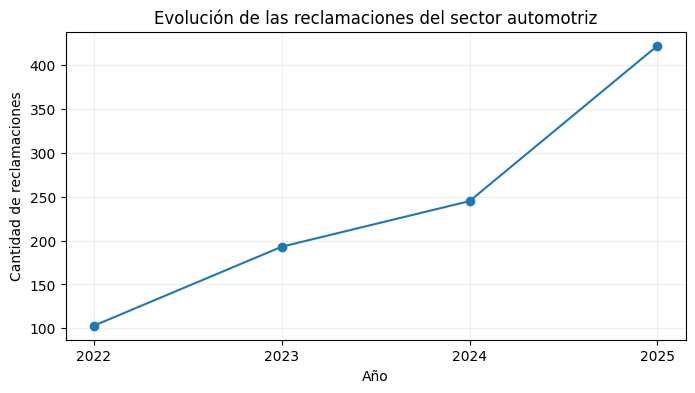

In [94]:
plt.figure(figsize=(8, 4))
plt.plot(reclamos_anio.index.astype(str), reclamos_anio.values, marker="o")
plt.title("Evolución de las reclamaciones del sector automotriz")
plt.xlabel("Año")
plt.ylabel("Cantidad de reclamaciones")
plt.grid(alpha=0.2)
plt.show()

# 13. Análisis por marca

El conteo por marca permite identificar cuáles aparecen con mayor frecuencia dentro de los registros de ACODECO.

> **No debe interpretarse como un ranking definitivo de riesgo.** Una marca que vende más vehículos también puede acumular más reclamaciones simplemente por tener mayor presencia en el mercado.

In [95]:
top_marcas = (
    df_final["Marca de Producto"]
    .value_counts()
    .head(15)
)

top_marcas

,count
Marca de Producto,
Hyundai,143
Toyota,135
KIA,121
Nissan,100
Chevrolet,69
Suzuki,44
Honda,42
Ford,31
Mitsubishi,29


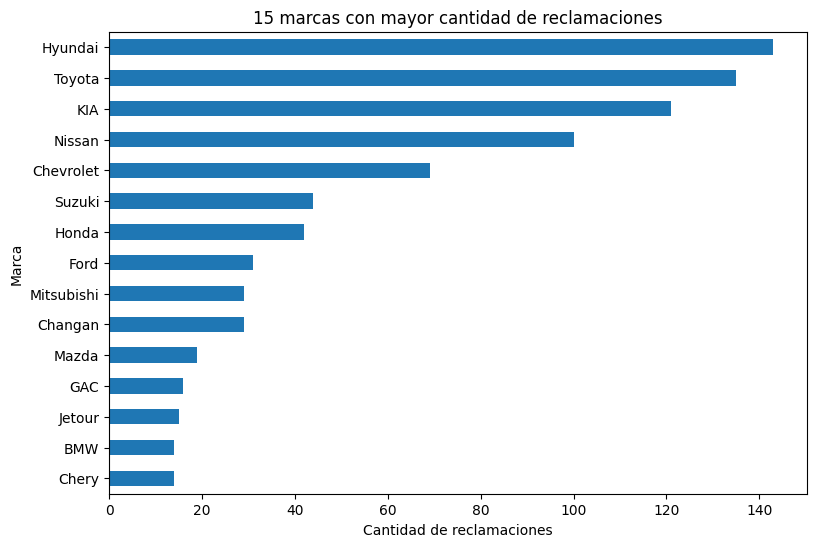

In [96]:
plt.figure(figsize=(9, 6))
top_marcas.sort_values().plot(kind="barh")
plt.title("15 marcas con mayor cantidad de reclamaciones")
plt.xlabel("Cantidad de reclamaciones")
plt.ylabel("Marca")
plt.show()

## 13.1 Resumen estadístico por marca

Con `groupby` se comparan tres elementos:

- cantidad de reclamaciones;
- monto promedio;
- monto mediano.

Para evitar conclusiones inestables, la tabla se muestra para las marcas con al menos 5 reclamaciones en el conjunto final.

In [97]:
resumen_marca = (
    df_final
    .groupby("Marca de Producto")["Velor de Apertura de Queja"]
    .agg(Cantidad="count", Media="mean", Mediana="median")
)

resumen_marca = (
    resumen_marca[resumen_marca["Cantidad"] >= 5]
    .sort_values("Cantidad", ascending=False)
)

resumen_marca.round(2).head(20)

,Cantidad,Media,Mediana
Marca de Producto,,,
Hyundai,143,7507.63,4280.00
Toyota,135,9954.96,7595.00
KIA,121,8293.53,6320.00
Nissan,100,7477.69,5000.00
Chevrolet,69,13595.51,15795.00
Suzuki,44,8137.68,4940.00
Honda,42,5440.63,3699.00
Ford,31,4734.78,2728.00
Mitsubishi,29,9153.40,2221.20


# 14. Distribución del indicador exploratorio de riesgo

Aquí observamos cuántas reclamaciones quedaron clasificadas como Bajo, Medio o Alto.

La gráfica sirve para describir el indicador que construimos. No sustituye la futura tasa de reclamaciones por cada 1,000 vehículos vendidos.

In [98]:
orden_riesgo = ["Bajo", "Medio", "Alto"]

conteo_riesgo = (
    df_final["Nivel_Riesgo"]
    .value_counts()
    .reindex(orden_riesgo)
)

conteo_riesgo

,count
Nivel_Riesgo,
Bajo,173
Medio,544
Alto,246


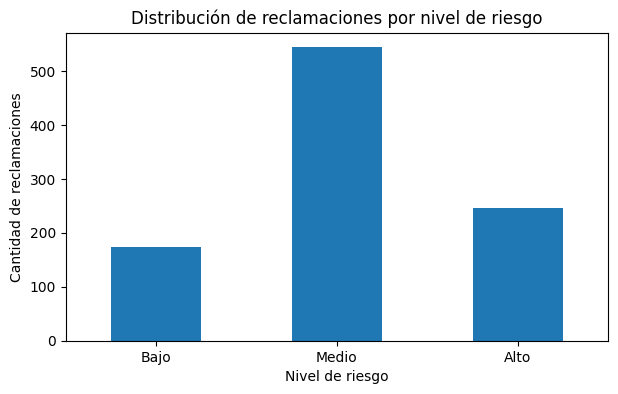

In [99]:
plt.figure(figsize=(7, 4))
conteo_riesgo.plot(kind="bar")
plt.title("Distribución de reclamaciones por nivel de riesgo")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Cantidad de reclamaciones")
plt.xticks(rotation=0)
plt.show()

## 14.1 Nivel de riesgo por año: porcentajes

Comparar solo cantidades puede ser engañoso cuando un año tiene más registros que otro.

Por eso usamos una tabla cruzada normalizada por fila: cada año suma 100 % y podemos comparar la **proporción** de reclamaciones Bajo, Medio y Alto.

In [100]:
riesgo_anio_pct = pd.crosstab(
    df_final["Año Recibido de Queja"].astype("Int64"),
    df_final["Nivel_Riesgo"],
    normalize="index"
) * 100

riesgo_anio_pct = riesgo_anio_pct.reindex(columns=orden_riesgo)
riesgo_anio_pct.round(2)

Nivel_Riesgo,Bajo,Medio,Alto
Año Recibido de Queja,,,
2022,19.42,71.84,8.74
2023,16.58,58.03,25.39
2024,17.14,51.43,31.43
2025,18.72,54.98,26.30


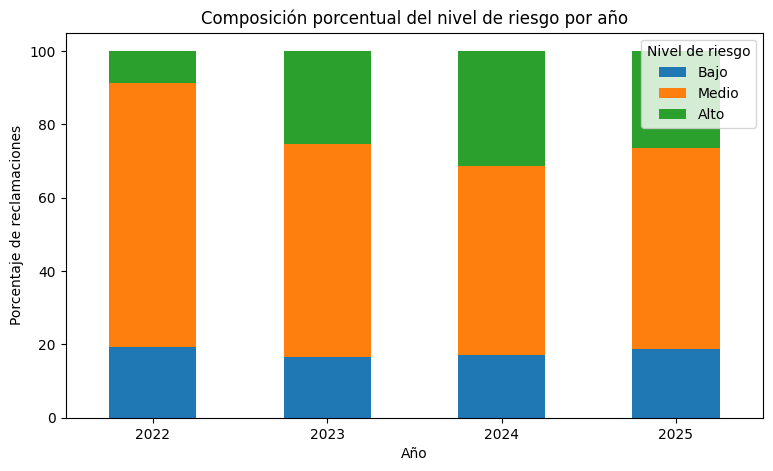

In [101]:
ax = riesgo_anio_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.title("Composición porcentual del nivel de riesgo por año")
plt.xlabel("Año")
plt.ylabel("Porcentaje de reclamaciones")
plt.xticks(rotation=0)
plt.legend(title="Nivel de riesgo")
plt.show()

# 15. Tabla dinámica: actividad × nivel de riesgo

Este ejercicio aplica `pivot_table`, visto en clase, para resumir el **monto mediano** según la actividad y el nivel de riesgo.

La mediana se utiliza porque es menos sensible a valores extremos que la media.

In [102]:
tabla_dinamica = pd.pivot_table(
    df_final,
    index="Actividad",
    columns="Nivel_Riesgo",
    values="Velor de Apertura de Queja",
    aggfunc="median"
)

tabla_dinamica = tabla_dinamica.reindex(columns=orden_riesgo)
tabla_dinamica.round(2)

Nivel_Riesgo,Bajo,Medio,Alto
Actividad,,,
Agencia de autos,346.4,12992.50,23248.3
Alquiler de autos,250.0,2000.00,19995.0
Repuestos para autos,267.5,342.89,NaN
Taller de reparación de autos,449.4,2387.90,NaN
Venta de autos usados,4135.0,6550.00,19559.6


# 16. Estandarización del monto

Aplicamos `StandardScaler`, contenido de la clase de preparación de datos.

La estandarización transforma el monto a una escala donde:

- la media es aproximadamente 0;
- la desviación estándar poblacional es aproximadamente 1.

Esto **no cambia el orden ni la forma general de los datos**. En este proyecto se utiliza como ejercicio y diagnóstico; el indicador de riesgo continúa trabajando con el monto original y sus cuartiles.

In [103]:
from sklearn.preprocessing import StandardScaler

escalador = StandardScaler()

df_final["Monto_z"] = escalador.fit_transform(
    df_final[["Velor de Apertura de Queja"]]
)

print("Media de Monto_z:", round(df_final["Monto_z"].mean(), 6))
print("Desviación estándar poblacional de Monto_z:", round(df_final["Monto_z"].std(ddof=0), 6))

df_final[
    ["Marca de Producto", "Velor de Apertura de Queja", "Monto_z"]
].sort_values("Monto_z", ascending=False).head(10)

Media de Monto_z: 0.0
Desviación estándar poblacional de Monto_z: 1.0


,Marca de Producto,Velor de Apertura de Queja,Monto_z
4547,Dongfeng,30000.00,2.095905
5873,Ford,30000.00,2.095905
3464,Forthing,30000.00,2.095905
4470,Chevrolet,29890.00,2.084195
4882,Hyundai,29889.01,2.084089
4553,KIA,29595.00,2.052791
436,Mitsubishi,29500.00,2.042679
3778,Volkswagen,29500.00,2.042679
2390,Hyundai,29499.00,2.042572
624,Mitsubishi,29495.00,2.042146


# 17. Correlación entre las variables numéricas del indicador

La matriz de correlación sirve como práctica del contenido de clase.

> **Precaución:** `Puntaje_Total` se construye sumando `Puntos_Motivo`, `Puntos_Resultado` y `Puntos_Monto`. Por eso es esperable encontrar correlaciones con sus componentes. No debe presentarse como una relación causal ni como un descubrimiento independiente.

In [104]:
variables_correlacion = [
    "Velor de Apertura de Queja",
    "Puntos_Motivo",
    "Puntos_Resultado",
    "Puntos_Monto",
    "Puntaje_Total"
]

correlaciones = df_final[variables_correlacion].corr()
correlaciones.round(3)

,Velor de Apertura de Queja,Puntos_Motivo,Puntos_Resultado,Puntos_Monto,Puntaje_Total
Velor de Apertura de Queja,1.000,0.358,0.055,0.866,0.734
Puntos_Motivo,0.358,1.000,0.002,0.324,0.803
Puntos_Resultado,0.055,0.002,1.000,0.097,0.235
Puntos_Monto,0.866,0.324,0.097,1.000,0.799
Puntaje_Total,0.734,0.803,0.235,0.799,1.000


# 18. Intervalo por remuestreo (bootstrap)

Para practicar el remuestreo visto en clase, estimamos un intervalo del 95 % para la **media del monto reclamado**.

El procedimiento toma muchas muestras con reemplazo del conjunto observado y recalcula la media en cada una. Esto permite observar qué tan variable podría ser la estimación.

In [105]:
rng = np.random.default_rng(42)
valores = df_final["Velor de Apertura de Queja"].dropna().to_numpy()

medias_bootstrap = []

for _ in range(2000):
    muestra = rng.choice(valores, size=len(valores), replace=True)
    medias_bootstrap.append(muestra.mean())

limite_boot_inf, limite_boot_sup = np.percentile(
    medias_bootstrap,
    [2.5, 97.5]
)

print("Media observada:", round(valores.mean(), 2))
print("Intervalo bootstrap 95%:",
      round(limite_boot_inf, 2), "a", round(limite_boot_sup, 2))

Media observada: 10311.3
Intervalo bootstrap 95%: 9729.45 a 10910.63


# 19. ¿Por qué todavía no entrenamos un modelo de Machine Learning?

En la Clase 7 se trabajó con `train_test_split`, modelos baseline, kNN y métricas.

En este proyecto **todavía no es metodológicamente conveniente entrenar un modelo para predecir `Nivel_Riesgo`**, porque esa variable fue creada directamente a partir de:

- `Motivo de Queja`;
- `Resultado de Queja`;
- `Monto reclamado`.

Si usamos esas mismas variables para predecirla, el modelo simplemente aprendería la regla que nosotros mismos definimos.

La aplicación de Machine Learning se deja para una fase posterior, después de integrar los datos de **ventas de ADAP** y otras variables externas. En ese momento se podrá definir una variable objetivo que responda realmente a la pregunta de investigación.

# 20. Próximo paso del proyecto

El cuaderno ya deja preparada la fuente ACODECO para continuar con la integración de datos.

El siguiente paso recomendado es:

1. incorporar las ventas de vehículos nuevos por marca y año;
2. homologar los nombres de marcas entre ACODECO y ADAP;
3. calcular reclamaciones por cada 1,000 vehículos vendidos;
4. comparar esa tasa con el indicador exploratorio construido aquí;
5. evaluar si existen suficientes datos para un análisis estadístico o un modelo predictivo válido.

Esto permitirá pasar de **conteos de reclamaciones** a una medida comparable de **riesgo poscompra por marca**.